# Stellar Mass Function

`phi(M) = dN / (dlog10M * V)` in units of (Mpc/h)^-3 dex^-1.

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

import galform_analysis
from galform_analysis import set_base_dir, get_base_dir, SimulationConfig, load_redshift_mapping

mpl.setconfig()

# Configure the path to your GALFORM output directory once per session:
# set_base_dir('/cosma5/data/durham/<user>/Galform_Out/L800/model')
BASE_DIR = str(get_base_dir())
SIM = 'L800'

## Single subvolume, single snapshot

In [2]:
from galform_analysis.analysis.mass_functions.smf import (
    smf_given_redshift_and_subvolume,
    avg_smf_given_redshift_and_subvolumes,
    avg_smf_given_redshifts_and_subvolume,
    smfs_given_redshifts_and_subvolume,
)
from galform_analysis.config import DEFAULT_STELLAR_MASS_BINS, get_snapshot_redshift
import os

iz_path = os.path.join(BASE_DIR, 'iz155')
res = smf_given_redshift_and_subvolume(iz_path, ivol=0)
print(f"z={res['z']:.4f},  V_ivol={res['V_ivol']:.1f} (Mpc/h)^3")

z=1.4955,  V_ivol=155626.1 (Mpc/h)^3


## Average over multiple subvolumes

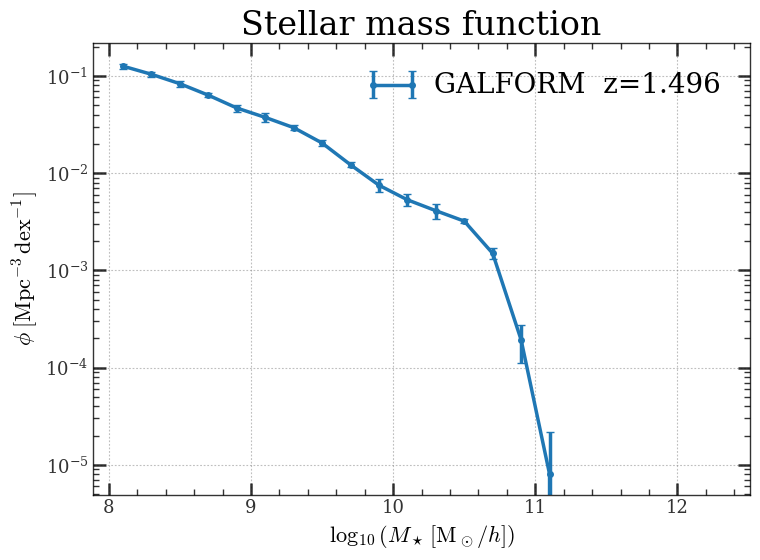

In [3]:
IZ_NUM = 155
IVOLS  = list(range(4))   # use more subvolumes for better statistics

z = get_snapshot_redshift(f'iz{IZ_NUM}', SIM)
res = avg_smf_given_redshift_and_subvolumes(IZ_NUM, IVOLS, base_dir=BASE_DIR)

fig, ax = plt.subplots()
ax.errorbar(res['centers'], res['phi'], yerr=res['phi_std'],
            fmt='o-', ms=4, capsize=3, label=f'GALFORM  z={z:.3f}')
ax.set_yscale('log')
ax.set_xlabel(r'$\log_{{10}}(M_\star\,[\mathrm{{M}}_\odot/h])$')
ax.set_ylabel(r'$\phi\;[\mathrm{{Mpc}}^{{-3}}\,\mathrm{{dex}}^{{-1}}]$')
ax.set_title('Stellar mass function')
ax.legend()
fig.tight_layout()
plt.show()

## Redshift evolution (one subvolume across multiple snapshots)

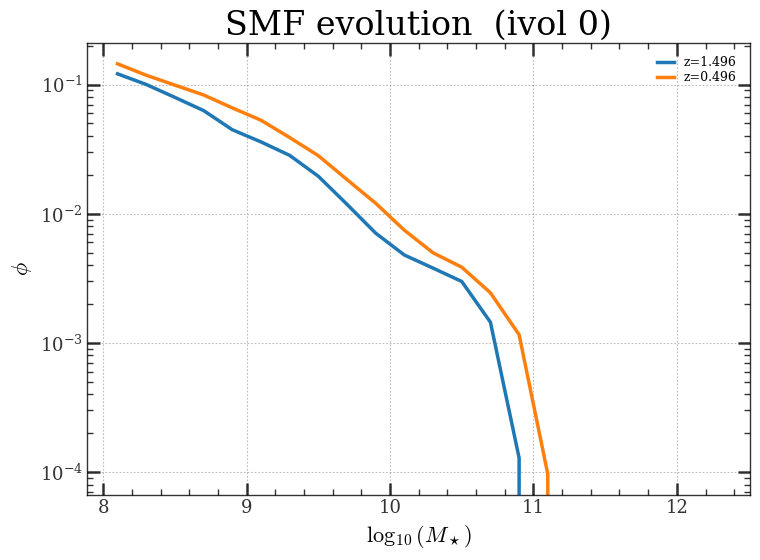

In [4]:
IZ_NUMS = [82, 120, 155, 207]   # adjust to snapshots available in your run
IVOL    = 0

import polars as pl
df = smfs_given_redshifts_and_subvolume(IVOL, IZ_NUMS, base_dir=BASE_DIR)
if df is None:
    print("No data — check IZ_NUMS match your simulation outputs.")
else:
    fig, ax = plt.subplots()
    for z_val, grp in df.group_by('z', maintain_order=True):
        z_val = z_val[0]
        ax.plot(grp['log_M'], grp['phi'], label=f'z={z_val:.3f}')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\log_{{10}}(M_\star)$')
    ax.set_ylabel(r'$\phi$')
    ax.set_title('SMF evolution  (ivol 0)')
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()